In [1]:
import sys

sys.path.append("../../../src/")

In [2]:
import pandas as pd
import numpy as np
from sts.quant.indicators.trend import trend_ewm
from sts.plots.time_series_plots import plot_multi_time_series
from sts.quant.indicators.volatility import vol_atr_scaled

## vol_atr_scaled

the vol_atr_scaled result depend on 2 parameters mainly:
1. the lookback window, the longer the look back window, the less likely it will impacted by short time vol jump
2. the scaled factor: which scale the daily vol to the scaled window based on random walk assumptions

In [3]:
time_index = pd.date_range(start="2023.01.01", end="2024.06.01", freq="1d")[:100]

value = np.asarray([0] * len(time_index))
value[-20:] = 1
df = pd.DataFrame(
    {"Open": value, "High": value + 0.2, "Low": value - 0.2, "Close": value},
    index=time_index,
)

<Axes: >

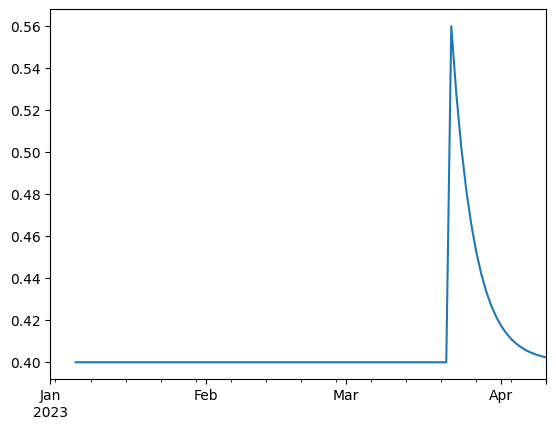

In [7]:
vol_atr_scaled(df, 5, 1).plot()

the atr calculate vol based on the price difference, so it is 0.4 before the jump and on the jump day is it (0.4 * 5 + 1.2 * 1)/5 = 0.56

Because of the ewm, the dacay is not as fast as rolling window. but it decay to the half heigh (0.56+0.40)/2 = 0.48 after half the window 5/2 = 3 days. 